<a href="https://colab.research.google.com/github/kelawady/Acoustic_Emissions/blob/main/Morlet_Wavelet_Detection_2_26_26_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount the drive

In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment2/'
FOLDERNAME = 'EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# Change directory to current path
%cd /content/drive/My\ Drive/$FOLDERNAME/
!pwd
!ls

Mounted at /content/drive
/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE
/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE
 AE_detection_results
 before_after_2bpf.png
 before_after_8KhzNpotch.png
 before_after_hpf.png
 hw1_prob2a.png
 P36_filt_20k_60K_segments
 P36_filt_2K_60K.npy
 P36_filt_2k_60K_segments
 P36_filtered_waveform_30-50_kHz.wav
 P36_filtered_waveform_32-46_kHz.wav
 P36_raw_segments
 P36_raw_waveform.wav
'Pillar 36_10um.DTA'
'Pillar 36_10um_Waveform20240721-194953-051.wfs'
 raw_signal_histogram.png
 raw_signal.png
 raw_signal_segments.png
 raw_signal_spectrogram.png


### Determine energy thresholds for different Morlet frequency bands prior to doing event detection

Notes

This estimates thresholds from the first noise_duration_s seconds by selecting segment files whose start sample is within that range (works because of your filename convention).

The threshold is per band because the energy metric scale can differ by frequency band.

The suggest_single_threshold_across_bands() helper is there, but in practice a single threshold across bands only makes sense if you normalize the per-band metrics (we can do that next if you want).

In [2]:
import numpy as np
import pywt

def targeted_cwt_energy_band(x, fs, f0_hz, delta_f_hz,
                             wavelet="morl",
                             voices=24):
    """
    Compute Morlet CWT energy over a narrow frequency band
    centered at f0_hz with half-width delta_f_hz.

    Returns
    -------
    metric : np.ndarray
        Energy vs time (sum |CWT|^2 across band scales)
    freqs_used : np.ndarray
        Frequencies used in the band
    """

    x = np.asarray(x, dtype=np.float32)
    x = x - np.median(x)

    # Define band
    f1 = max(1e-9, f0_hz - delta_f_hz)
    f2 = f0_hz + delta_f_hz

    # Constrain to Nyquist
    f2 = min(f2, 0.49 * fs)
    if f1 >= f2:
        raise ValueError(f"Invalid frequency band [{f1}, {f2}]")

    # Log-spaced frequency grid inside band
    n_oct = np.log2(f2 / f1)
    n_freqs = max(2, int(np.ceil(n_oct * voices)) + 1)
    freqs = f1 * (2 ** (np.arange(n_freqs) / voices))

    # Convert frequencies to scales
    fc = pywt.central_frequency(wavelet)
    scales = fc * fs / freqs

    # Compute CWT only at these scales
    coeffs, _ = pywt.cwt(x, scales, wavelet, sampling_period=1/fs)

    # Energy metric across band
    metric = np.sum(np.abs(coeffs) ** 2, axis=0)

    return metric, freqs

def robust_threshold_from_values(values, k=6.0):
    """
    Compute a robust threshold using median + k * robust_sigma.

    Parameters
    ----------
    values : array-like
        1D array of metric values (e.g., energy samples from noise region)
    k : float
        Threshold multiplier (larger = more conservative)

    Returns
    -------
    threshold : float
    median : float
    mad : float
    sigma_robust : float   (1.4826 * MAD)
    """

    v = np.asarray(values, dtype=np.float64)

    if v.size == 0:
        raise ValueError("Input array is empty.")

    median = np.median(v)
    mad = np.median(np.abs(v - median))

    # Convert MAD to Gaussian-equivalent sigma
    sigma_robust = 1.4826 * mad

    threshold = median + k * sigma_robust

    return float(threshold), float(median), float(mad), float(sigma_robust)

In [8]:
from pathlib import Path
from tqdm.auto import tqdm


def list_segment_files(segment_dir, prefix="P36_filt"):
    segment_dir = Path(segment_dir)
    files = sorted(segment_dir.glob(f"{prefix}_*_*.npy"))
    if not files:
        raise FileNotFoundError(f"No segment files found in {segment_dir} with prefix '{prefix}'")
    return files


def parse_segment_start_from_filename(fname):
    # expects P36_filt_<start>_<end>.npy
    parts = Path(fname).stem.split("_")
    if len(parts) < 4:
        raise ValueError(f"Unexpected filename format: {fname}")
    return int(parts[2])


def estimate_noise_thresholds_per_wavelet_band(
    segment_dir,
    fs,
    freq_bands_hz,
    *,
    prefix="P36_filt",   # <-- updated default prefix
    wavelet="morl",
    delta_f_default_hz=None,
    k=6.0,
    noise_duration_s=2.0,
    subsample_step=20,
    max_values_per_band=500_000,
    voices=24,
):
    files = list_segment_files(segment_dir, prefix=prefix)

    noise_end_sample = int(round(noise_duration_s * fs))

    noise_files = []
    for fp in files:
        s0 = parse_segment_start_from_filename(fp.name)
        if s0 < noise_end_sample:
            noise_files.append(fp)
        else:
            break

    if not noise_files:
        raise ValueError("No noise files selected. Increase noise_duration_s or check filenames.")

    bands = []
    for i, b in enumerate(freq_bands_hz):
        if isinstance(b, dict):
            f0 = float(b["f0_hz"])
            df = float(b["delta_f_hz"])
            name = b.get("name", f"band_{int(f0)}")
        elif isinstance(b, (tuple, list)) and len(b) == 2:
            f0, df = map(float, b)
            name = f"band_{int(f0)}"
        else:
            f0 = float(b)
            if delta_f_default_hz is None:
                raise ValueError("delta_f_default_hz must be provided if bands are single values.")
            df = float(delta_f_default_hz)
            name = f"band_{int(f0)}"

        bands.append({"name": name, "f0_hz": f0, "delta_f_hz": df})

    collected = {b["name"]: [] for b in bands}
    n_files_used = {b["name"]: 0 for b in bands}

    for fp in tqdm(noise_files, desc="Estimating thresholds from noise-only files"):
        x = np.load(fp, mmap_mode="r")

        for b in bands:
            metric, _ = targeted_cwt_energy_band(
                x, fs, b["f0_hz"], b["delta_f_hz"], wavelet=wavelet, voices=voices
            )

            vals = metric[::subsample_step].astype(np.float32, copy=False)
            collected[b["name"]].append(vals)
            n_files_used[b["name"]] += 1

            total_vals = sum(arr.size for arr in collected[b["name"]])
            if total_vals >= max_values_per_band:
                allv = np.concatenate(collected[b["name"]])[:max_values_per_band]
                collected[b["name"]] = [allv]

    thresholds = {}
    for b in bands:
        name = b["name"]
        all_vals = np.concatenate(collected[name]).astype(np.float64, copy=False)

        thr, med, mad, sigma = robust_threshold_from_values(all_vals, k=k)

        thresholds[name] = {
            "f0_hz": b["f0_hz"],
            "delta_f_hz": b["delta_f_hz"],
            "thr": thr,
            "median": med,
            "mad": mad,
            "sigma_robust": sigma,
            "k": float(k),
            "n_values": int(all_vals.size),
            "n_files_used": int(n_files_used[name]),
        }

    return thresholds

In [10]:
segment_dir = "P36_filt_2k_60K_segments"
fs = 2_000_000

freq_bands = [
    {"name": "8k",  "f0_hz":  8_000, "delta_f_hz": 2_000},
    {"name": "16k", "f0_hz": 16_000, "delta_f_hz": 3_000},
    {"name": "25k", "f0_hz": 25_000, "delta_f_hz": 5_000},
    {"name": "44k", "f0_hz": 44_000, "delta_f_hz": 8_000},
]

thresholds = estimate_noise_thresholds_per_wavelet_band(
    segment_dir,
    fs=fs,
    freq_bands_hz=freq_bands,
    noise_duration_s=10.0,
    k=6.0
)

for name, info in thresholds.items():
    print(name, "-> threshold =", info["thr"])

Estimating thresholds from noise-only files:   0%|          | 0/1 [00:00<?, ?it/s]

8k -> threshold = 3.727300564152002
16k -> threshold = 2.0000516887143256
25k -> threshold = 1.3835881327331065
44k -> threshold = 0.6474409708179534


### Detect the seismic events

For each of the wavelet bands, identify whether an 'event' occured (namely the presence of a seismic event centered around that wavelet's frequency band).

When we detect events, we want to note where the event took place and its duration. If an event is detected then record:
- the file where it happened
- The index in the file where it starts
- The index in the file where it ends
- The implied global start time
- The duration in microseconds


In [7]:
# ----------------------------
# File helpers (P36_filt prefix)
# ----------------------------
def list_segment_files(segment_dir, prefix="P36_filt"):
    segment_dir = Path(segment_dir)
    files = sorted(segment_dir.glob(f"{prefix}_*_*.npy"))
    if not files:
        raise FileNotFoundError(f"No segment files found in {segment_dir} with prefix '{prefix}'")
    return files

def parse_segment_bounds_from_filename(fname):
    # expects: P36_filt_<start>_<end>.npy  (end is inclusive)
    parts = Path(fname).stem.split("_")
    if len(parts) < 4:
        raise ValueError(f"Unexpected filename format: {fname}")
    seg_start = int(parts[2])
    seg_end_inc = int(parts[3])
    return seg_start, seg_end_inc


# ----------------------------
# Wavelet band energy (Morlet)
# ----------------------------
def targeted_cwt_energy_band(x, fs, f0_hz, delta_f_hz, wavelet="morl", voices=24):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.median(x)

    f1 = max(1e-9, float(f0_hz - delta_f_hz))
    f2 = float(f0_hz + delta_f_hz)

    f2 = min(f2, 0.49 * fs)
    if f1 >= f2:
        raise ValueError(f"Invalid band for f0={f0_hz}: [{f1},{f2}] with fs={fs}")

    n_oct = np.log2(f2 / f1)
    n_freqs = max(2, int(np.ceil(n_oct * voices)) + 1)
    freqs = f1 * (2 ** (np.arange(n_freqs) / voices))

    fc = pywt.central_frequency(wavelet)
    scales = fc * fs / freqs

    coeffs, _ = pywt.cwt(x, scales, wavelet, sampling_period=1/fs)
    metric = np.sum(np.abs(coeffs) ** 2, axis=0)
    return metric, freqs


# ----------------------------
# Event finding utilities
# ----------------------------
def smooth_1d(x, win):
    if win is None or win <= 1:
        return x
    win = int(win)
    kernel = np.ones(win, dtype=np.float32) / win
    return np.convolve(x, kernel, mode="same")

def find_events_above_threshold(metric, thr, min_len_samples=0):
    """Return list of (start_idx, end_idx) inclusive for metric > thr."""
    above = metric > thr
    if not np.any(above):
        return []
    idx = np.flatnonzero(above)
    breaks = np.where(np.diff(idx) > 1)[0]
    runs = np.split(idx, breaks + 1)
    events = []
    for r in runs:
        s, e = int(r[0]), int(r[-1])
        if min_len_samples and (e - s + 1) < min_len_samples:
            continue
        events.append((s, e))
    return events


# ----------------------------
# Detection runner
# ----------------------------
def detect_events_per_band(
    segment_dir,
    fs,
    bands,          # list of dicts: {"name","f0_hz","delta_f_hz"}
    thresholds,     # dict keyed by band["name"], with thresholds[name]["thr"]
    *,
    prefix="P36_filt",
    wavelet="morl",
    voices=24,
    smooth_samples=0,
    min_event_samples=0,
    max_files=None,
    show_progress=True,
):
    """
    Scans each segmented file and detects events per frequency band.

    Returns
    -------
    events_by_band : dict[str, list[dict]]
      Each event dict contains:
        - band
        - filename
        - file_start_idx
        - file_end_idx_inclusive
        - segment_global_start_sample
        - event_global_start_sample
        - event_global_end_sample_inclusive
        - global_start_time_s
        - duration_us
        - threshold_used
    """
    files = list_segment_files(segment_dir, prefix=prefix)
    if max_files is not None:
        files = files[:max_files]

    events_by_band = {b["name"]: [] for b in bands}

    it = tqdm(files, desc="Detecting events") if show_progress else files
    for fp in it:
        seg_start, seg_end_inc = parse_segment_bounds_from_filename(fp.name)
        x = np.load(fp, mmap_mode="r")
        N = len(x)

        for b in bands:
            name = b["name"]
            thr = float(thresholds[name]["thr"])

            metric, _ = targeted_cwt_energy_band(
                x, fs, b["f0_hz"], b["delta_f_hz"], wavelet=wavelet, voices=voices
            )
            metric = smooth_1d(metric, smooth_samples)

            events = find_events_above_threshold(metric, thr, min_len_samples=min_event_samples)
            if not events:
                continue

            for s, e in events:
                # clamp to file length just in case
                s = max(0, min(int(s), N - 1))
                e = max(0, min(int(e), N - 1))
                if e < s:
                    continue

                event_global_start = seg_start + s
                event_global_end = seg_start + e  # inclusive

                ev = {
                    "band": name,
                    "filename": fp.name,
                    "file_start_idx": s,
                    "file_end_idx_inclusive": e,
                    "segment_global_start_sample": seg_start,
                    "event_global_start_sample": event_global_start,
                    "event_global_end_sample_inclusive": event_global_end,
                    "global_start_time_s": event_global_start / fs,
                    "duration_us": (e - s + 1) / fs * 1e6,
                    "threshold_used": thr,
                }
                events_by_band[name].append(ev)

    # Sort each band chronologically by global start sample
    for name in events_by_band:
        events_by_band[name].sort(key=lambda d: d["event_global_start_sample"])

    return events_by_band


# ----------------------------
# Overlap reporting
# ----------------------------
def compute_overlaps(events_by_band, *, overlap_if_intersects=True):
    """
    Find overlaps between bands based on global sample intervals.

    Returns
    -------
    overlaps : list of dict
      Each dict: {band_a, band_b, a_idx, b_idx, overlap_start, overlap_end, overlap_duration_us}
    """
    band_names = list(events_by_band.keys())
    overlaps = []

    for i in range(len(band_names)):
        for j in range(i + 1, len(band_names)):
            a = band_names[i]
            b = band_names[j]
            evA = events_by_band[a]
            evB = events_by_band[b]

            # two-pointer scan since both lists are sorted by start time
            ia = ib = 0
            while ia < len(evA) and ib < len(evB):
                A = evA[ia]
                B = evB[ib]

                a0, a1 = A["event_global_start_sample"], A["event_global_end_sample_inclusive"]
                b0, b1 = B["event_global_start_sample"], B["event_global_end_sample_inclusive"]

                # intersection?
                s = max(a0, b0)
                e = min(a1, b1)
                if s <= e:
                    overlaps.append({
                        "band_a": a,
                        "band_b": b,
                        "a_event_start": a0,
                        "a_event_end": a1,
                        "b_event_start": b0,
                        "b_event_end": b1,
                        "overlap_start": s,
                        "overlap_end": e,
                        "overlap_samples": (e - s + 1),
                    })

                # advance the one that ends first
                if a1 < b1:
                    ia += 1
                else:
                    ib += 1

    return overlaps


def print_detection_summary(events_by_band, overlaps, fs):
    print("\n=== Event counts per band ===")
    for band, evs in events_by_band.items():
        print(f"{band}: {len(evs)} events")

    print("\n=== Overlaps between bands ===")
    if not overlaps:
        print("No overlaps found.")
        return

    # Summarize overlap counts per band-pair
    pair_counts = {}
    for o in overlaps:
        key = (o["band_a"], o["band_b"])
        pair_counts[key] = pair_counts.get(key, 0) + 1

    for (a, b), cnt in sorted(pair_counts.items(), key=lambda x: -x[1]):
        print(f"{a} ↔ {b}: {cnt} overlaps")

    # Print a few example overlaps (chronological by overlap start)
    overlaps_sorted = sorted(overlaps, key=lambda d: d["overlap_start"])
    print("\nFirst 10 overlaps (global time):")
    for o in overlaps_sorted[:10]:
        dur_us = o["overlap_samples"] / fs * 1e6
        t0 = o["overlap_start"] / fs
        t1 = o["overlap_end"] / fs
        print(f"{o['band_a']}↔{o['band_b']}  overlap [{t0:.6f}s, {t1:.6f}s]  dur={dur_us:.2f}µs")


In [13]:
# ---------------- Example usage ----------------
#
# thresholds must be produced by estimate_noise_thresholds_per_wavelet_band(...)
# # thresholds[name]["thr"] is used here.
#
events_by_band = detect_events_per_band(
    segment_dir,
    fs=fs,
    bands=freq_bands,
    thresholds=thresholds,
    prefix="P36_filt",
    wavelet="morl",
    voices=24,
    smooth_samples=64,       # optional, helps suppress tiny spikes
    min_event_samples=200,   # optional, enforce minimum duration
)

overlaps = compute_overlaps(events_by_band)
print_detection_summary(events_by_band, overlaps, fs)

# If you want a flat list of records:
all_events = [ev for band in events_by_band for ev in events_by_band[band]]
# sort globally:
all_events.sort(key=lambda d: d["event_global_start_sample"])
all_events[:5]

Detecting events:   0%|          | 0/138 [00:00<?, ?it/s]


=== Event counts per band ===
8k: 23 events
16k: 1632 events
25k: 174 events
44k: 203 events

=== Overlaps between bands ===
25k ↔ 44k: 110 overlaps
16k ↔ 44k: 101 overlaps
16k ↔ 25k: 91 overlaps
8k ↔ 25k: 24 overlaps
8k ↔ 16k: 23 overlaps
8k ↔ 44k: 23 overlaps

First 10 overlaps (global time):
16k↔44k  overlap [16.969876s, 16.969981s]  dur=106.00µs
16k↔25k  overlap [16.969887s, 16.969990s]  dur=102.50µs
25k↔44k  overlap [16.969887s, 16.969981s]  dur=94.00µs
16k↔25k  overlap [22.226774s, 22.226881s]  dur=107.50µs
16k↔44k  overlap [22.226792s, 22.226893s]  dur=101.50µs
25k↔44k  overlap [22.226792s, 22.226881s]  dur=90.00µs
16k↔25k  overlap [28.594493s, 28.594601s]  dur=108.50µs
16k↔44k  overlap [28.594506s, 28.594601s]  dur=96.50µs
25k↔44k  overlap [28.594506s, 28.594606s]  dur=101.00µs
25k↔44k  overlap [28.594960s, 28.595095s]  dur=135.00µs


[{'band': '16k',
  'filename': 'P36_filt_0_1999999.npy',
  'file_start_idx': 71430,
  'file_end_idx_inclusive': 71689,
  'segment_global_start_sample': 0,
  'event_global_start_sample': 71430,
  'event_global_end_sample_inclusive': 71689,
  'global_start_time_s': 0.035715,
  'duration_us': 130.0,
  'threshold_used': 2.0000516887143256},
 {'band': '16k',
  'filename': 'P36_filt_0_1999999.npy',
  'file_start_idx': 471171,
  'file_end_idx_inclusive': 471411,
  'segment_global_start_sample': 0,
  'event_global_start_sample': 471171,
  'event_global_end_sample_inclusive': 471411,
  'global_start_time_s': 0.2355855,
  'duration_us': 120.5,
  'threshold_used': 2.0000516887143256},
 {'band': '16k',
  'filename': 'P36_filt_0_1999999.npy',
  'file_start_idx': 885165,
  'file_end_idx_inclusive': 885386,
  'segment_global_start_sample': 0,
  'event_global_start_sample': 885165,
  'event_global_end_sample_inclusive': 885386,
  'global_start_time_s': 0.4425825,
  'duration_us': 111.0,
  'threshold_u

### Save results

In [14]:
import json
import csv
import numpy as np
from pathlib import Path


def save_detection_outputs(
    output_dir,
    events_by_band,
    overlaps,
    thresholds,
    fs
):
    """
    Saves:
      - Per-band CSV files
      - Combined events CSV
      - Overlaps CSV
      - Thresholds JSON
      - Summary JSON
      - Numpy NPZ archive
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # -------------------------
    # 1) Save per-band events
    # -------------------------
    for band, events in events_by_band.items():
        csv_file = output_dir / f"events_{band}.csv"

        if not events:
            continue

        keys = list(events[0].keys())

        with open(csv_file, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=keys)
            writer.writeheader()
            writer.writerows(events)

    # -------------------------
    # 2) Save combined events
    # -------------------------
    all_events = []
    for band in events_by_band:
        all_events.extend(events_by_band[band])

    all_events.sort(key=lambda d: d["event_global_start_sample"])

    combined_csv = output_dir / "events_all_bands.csv"
    if all_events:
        keys = list(all_events[0].keys())
        with open(combined_csv, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=keys)
            writer.writeheader()
            writer.writerows(all_events)

    # -------------------------
    # 3) Save overlaps
    # -------------------------
    overlaps_csv = output_dir / "band_overlaps.csv"
    if overlaps:
        keys = list(overlaps[0].keys())
        with open(overlaps_csv, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=keys)
            writer.writeheader()
            writer.writerows(overlaps)

    # -------------------------
    # 4) Save thresholds
    # -------------------------
    thresholds_file = output_dir / "thresholds.json"
    with open(thresholds_file, "w") as f:
        json.dump(thresholds, f, indent=4)

    # -------------------------
    # 5) Save summary
    # -------------------------
    summary = {
        "fs": fs,
        "event_counts_per_band": {band: len(events_by_band[band])
                                  for band in events_by_band},
        "total_events": len(all_events),
        "total_overlaps": len(overlaps)
    }

    summary_file = output_dir / "summary.json"
    with open(summary_file, "w") as f:
        json.dump(summary, f, indent=4)

    # -------------------------
    # 6) Save compressed NumPy archive
    # -------------------------
    npz_file = output_dir / "all_detection_data.npz"
    np.savez_compressed(
        npz_file,
        events_by_band=events_by_band,
        overlaps=overlaps,
        thresholds=thresholds,
        summary=summary
    )

    print("\nAll outputs saved to:", output_dir)

In [15]:
output_dir = "AE_detection_results"

save_detection_outputs(
    output_dir,
    events_by_band,
    overlaps,
    thresholds,
    fs
)


All outputs saved to: AE_detection_results


### Understanding events

#### If just loading saved results start here

In [3]:
import numpy as np
from pathlib import Path

def load_detection_outputs(output_dir):
    output_dir = Path(output_dir)
    npz_file = output_dir / "all_detection_data.npz"

    with np.load(npz_file, allow_pickle=True) as data:
        events_by_band = data["events_by_band"].item()
        thresholds = data["thresholds"].item()
        summary = data["summary"].item()

        overlaps_obj = data["overlaps"]

        # overlaps may be 0-d object or 1-d object array
        if overlaps_obj.shape == ():
            overlaps = overlaps_obj.item()
        else:
            overlaps = overlaps_obj.tolist()

    return events_by_band, overlaps, thresholds, summary

In [4]:
events_by_band, overlaps, thresholds, summary = \
    load_detection_outputs("AE_detection_results")

print(summary)

{'fs': 2000000, 'event_counts_per_band': {'8k': 23, '16k': 1632, '25k': 174, '44k': 203}, 'total_events': 2032, 'total_overlaps': 372}


In [5]:
print(len(events_by_band["8k"]))
print(events_by_band["8k"][0])

23
{'band': '8k', 'filename': 'P36_filt_90000000_91999999.npy', 'file_start_idx': 1514137, 'file_end_idx_inclusive': 1514712, 'segment_global_start_sample': 90000000, 'event_global_start_sample': 91514137, 'event_global_end_sample_inclusive': 91514712, 'global_start_time_s': 45.7570685, 'duration_us': 288.0, 'threshold_used': 3.727300564152002}


In [6]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def _load_event_waveform(fp, start_idx, end_idx_inc):
    x = np.load(fp, mmap_mode="r")
    return np.asarray(x[start_idx:end_idx_inc + 1], dtype=np.float32)


def _collect_band_waveforms(segment_dir, band_events, *, max_events=None):
    segment_dir = Path(segment_dir)
    evs = band_events if max_events is None else band_events[:max_events]
    wfs = []
    for ev in tqdm(evs, desc="Loading event waveforms", leave=False):
        fp = segment_dir / ev["filename"]
        wfs.append(_load_event_waveform(fp, ev["file_start_idx"], ev["file_end_idx_inclusive"]))
    return wfs


def _pad_or_crop_to_length(waveforms, L):
    out = []
    for wf in waveforms:
        wf = np.asarray(wf, dtype=np.float32)
        if len(wf) >= L:
            out.append(wf[:L])
        else:
            out.append(np.pad(wf, (0, L - len(wf)), mode="constant"))
    return out


def plot_overlaid_events_time_and_spectrum_4bands(
    segment_dir,
    fs,
    events_by_band,
    band_names,
    *,
    n_overlay_per_band=None,      # None = all
    time_figsize=(14, 10),
    spec_figsize=(14, 10),
    avg_spec_figsize=(14, 10),
    use_hann_window=False,
):
    """
    Creates THREE figures:
      1) 4x1 time-domain overlays (one subplot per band) with PER-BAND duration
      2) 4x1 magnitude spectrum overlays (one subplot per band), limited to 0..60kHz
      3) 4x1 averaged magnitude spectrum (mean across events per band), limited to 0..60kHz

    Updates implemented:
      - Each time subplot uses its OWN max event duration for that band (not global)
      - Each time subplot has its OWN x-axis labeling/limits (no sharex)
      - Frequency plots fixed to 0..60 kHz
    """

    # -------------------------
    # Load waveforms per band
    # -------------------------
    band_wfs_raw = {}
    band_max_len = {}

    for bn in band_names:
        evs = events_by_band.get(bn, [])
        if not evs:
            band_wfs_raw[bn] = []
            band_max_len[bn] = 0
            continue

        wfs = _collect_band_waveforms(segment_dir, evs, max_events=n_overlay_per_band)
        band_wfs_raw[bn] = wfs
        band_max_len[bn] = max(len(w) for w in wfs) if wfs else 0

    if all(band_max_len[bn] <= 1 for bn in band_names):
        raise ValueError("No events found (or event lengths invalid) for the given band_names.")

    # -------------------------
    # Global y-limits (time) across all bands (to keep comparable)
    # NOTE: uses raw (unpadded) waveforms
    # -------------------------
    all_time_vals = []
    for bn in band_names:
        if band_wfs_raw[bn]:
            all_time_vals.append(np.concatenate(band_wfs_raw[bn]))
    y_min = float(np.min(np.concatenate(all_time_vals)))
    y_max = float(np.max(np.concatenate(all_time_vals)))

    # ===============================
    # 1) Time-domain overlays (per-band duration)
    # ===============================
    fig, axes = plt.subplots(4, 1, figsize=time_figsize, sharey=True)
    fig.suptitle("Event time-domain overlays (by band) — per-band max duration", y=0.995)

    for ax, bn in zip(axes, band_names):
        wfs = band_wfs_raw[bn]
        Lb = band_max_len[bn]

        if not wfs or Lb <= 1:
            ax.set_title(f"{bn}: 0 events")
            ax.set_ylabel("Amplitude")
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("Time (µs)")  # still label for consistency
            continue

        # pad/crop each waveform to this band's max length
        wfs_b = _pad_or_crop_to_length(wfs, Lb)
        t_us = (np.arange(Lb) / fs) * 1e6

        for wf in wfs_b:
            ax.plot(t_us, wf, linewidth=0.6, alpha=0.35)

        ax.set_title(f"{bn}: {len(wfs_b)} events (duration up to {t_us[-1]:.2f} µs)")
        ax.set_ylabel("Amplitude")
        ax.set_xlim(t_us[0], t_us[-1])
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Time (µs)")  # per-subplot label (not shared x)

    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

    # ===============================
    # 2) Spectrum overlays (0..60kHz)
    # ===============================
    f_plot_min = 0.0
    f_plot_max = 60_000.0

    band_mags = {}
    all_mag_vals = []

    for bn in band_names:
        wfs = band_wfs_raw[bn]
        Lb = band_max_len[bn]

        if not wfs or Lb <= 1:
            band_mags[bn] = {"freqs": None, "mags": []}
            continue

        wfs_b = _pad_or_crop_to_length(wfs, Lb)

        freqs = np.fft.rfftfreq(Lb, d=1/fs)
        fmask = (freqs >= f_plot_min) & (freqs <= f_plot_max)
        freqs_p = freqs[fmask]

        window = np.hanning(Lb).astype(np.float32) if use_hann_window else None

        mags = []
        for wf in wfs_b:
            xw = wf * window if window is not None else wf
            X = np.fft.rfft(xw)
            mag = np.abs(X)[fmask]
            mags.append(mag)

        band_mags[bn] = {"freqs": freqs_p, "mags": mags}
        if mags:
            all_mag_vals.append(np.concatenate(mags))

    if all_mag_vals:
        mag_min = float(np.min(np.concatenate(all_mag_vals)))
        mag_max = float(np.max(np.concatenate(all_mag_vals)))
    else:
        mag_min, mag_max = 0.0, 1.0

    fig, axes = plt.subplots(4, 1, figsize=spec_figsize, sharex=True, sharey=True)
    fig.suptitle("Event magnitude spectrum overlays (by band), f in [0, 60 kHz]", y=0.995)

    for ax, bn in zip(axes, band_names):
        freqs_p = band_mags[bn]["freqs"]
        mags = band_mags[bn]["mags"]

        if freqs_p is None or not mags:
            ax.set_title(f"{bn}: 0 events")
            ax.set_ylabel("|FFT|")
            ax.grid(True, alpha=0.3)
            continue

        for mag in mags:
            ax.plot(freqs_p, mag, linewidth=0.6, alpha=0.35)

        ax.set_title(f"{bn}: {len(mags)} events")
        ax.set_ylabel("|FFT|")
        ax.set_xlim(f_plot_min, f_plot_max)
        ax.set_ylim(mag_min, mag_max)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Frequency (Hz)")
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

    # ===============================
    # 3) Averaged spectrum (0..60kHz)
    # ===============================
    band_avg = {}
    band_n = {}
    avg_vals = []

    for bn in band_names:
        mags = band_mags[bn]["mags"]
        freqs_p = band_mags[bn]["freqs"]
        if freqs_p is None or not mags:
            band_avg[bn] = None
            band_n[bn] = 0
            continue
        M = np.stack(mags, axis=0)
        avg = np.mean(M, axis=0)
        band_avg[bn] = avg
        band_n[bn] = M.shape[0]
        avg_vals.append(avg)

    if avg_vals:
        avg_min = float(np.min(np.concatenate(avg_vals)))
        avg_max = float(np.max(np.concatenate(avg_vals)))
    else:
        avg_min, avg_max = 0.0, 1.0

    fig, axes = plt.subplots(4, 1, figsize=avg_spec_figsize, sharex=True, sharey=True)
    fig.suptitle("Averaged event magnitude spectra (mean over events), f in [0, 60 kHz]", y=0.995)

    for ax, bn in zip(axes, band_names):
        freqs_p = band_mags[bn]["freqs"]
        avg = band_avg[bn]

        if freqs_p is None or avg is None:
            ax.set_title(f"{bn}: 0 events")
            ax.set_ylabel("Mean |FFT|")
            ax.grid(True, alpha=0.3)
            continue

        ax.plot(freqs_p, avg, linewidth=1.2)
        ax.set_title(f"{bn}: mean spectrum over {band_n[bn]} events")
        ax.set_ylabel("Mean |FFT|")
        ax.set_xlim(f_plot_min, f_plot_max)
        ax.set_ylim(avg_min, avg_max)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Frequency (Hz)")
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

    return band_mags, band_avg, band_n

Loading event waveforms:   0%|          | 0/23 [00:00<?, ?it/s]

Loading event waveforms:   0%|          | 0/200 [00:00<?, ?it/s]

Loading event waveforms:   0%|          | 0/174 [00:00<?, ?it/s]

Loading event waveforms:   0%|          | 0/200 [00:00<?, ?it/s]

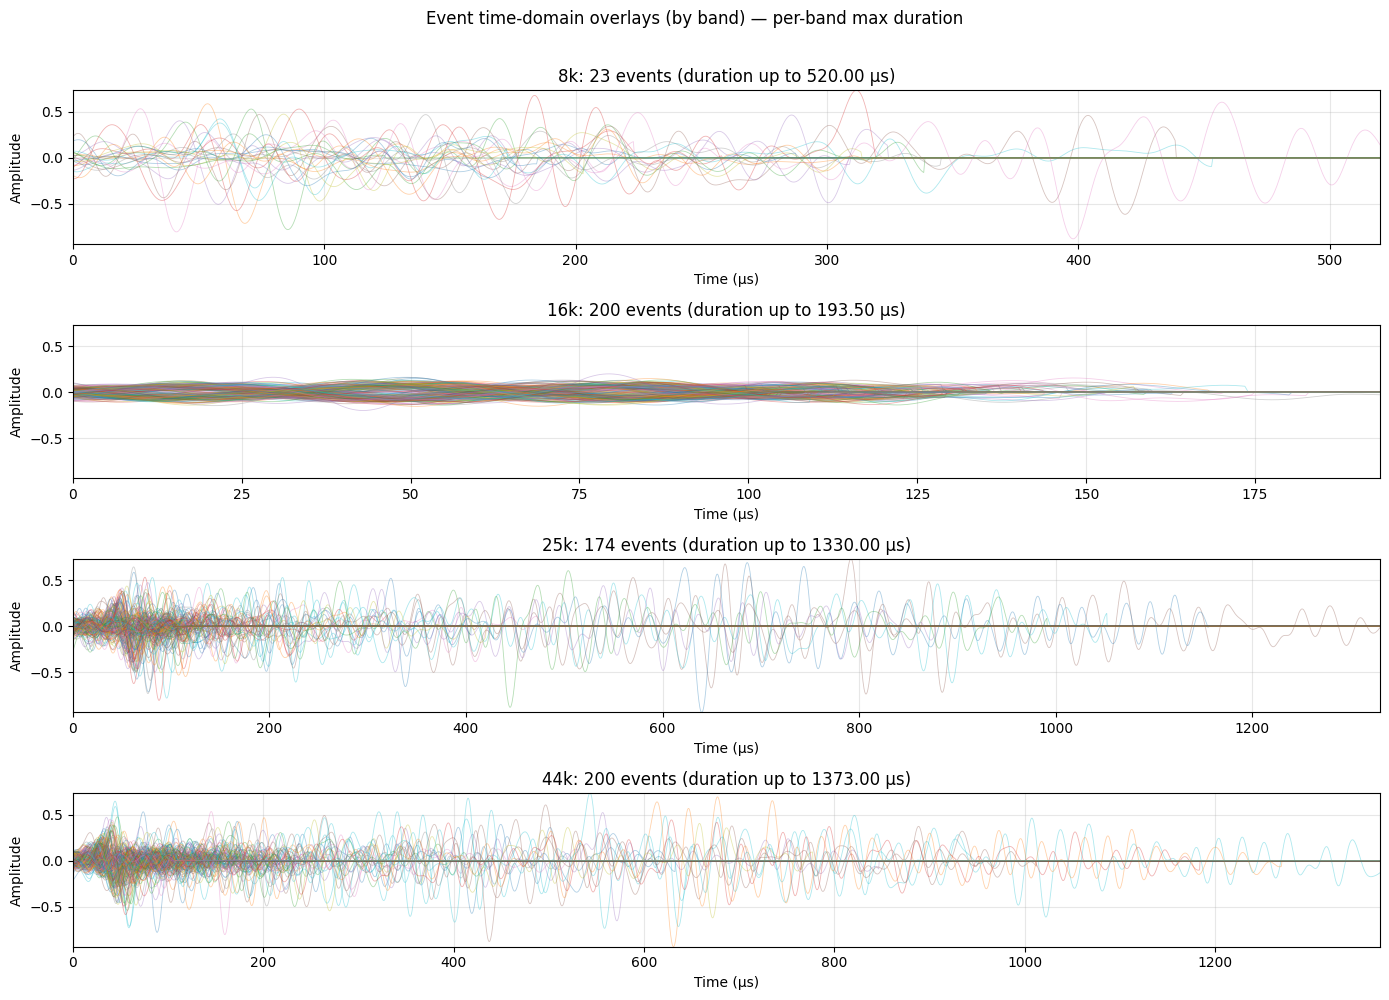

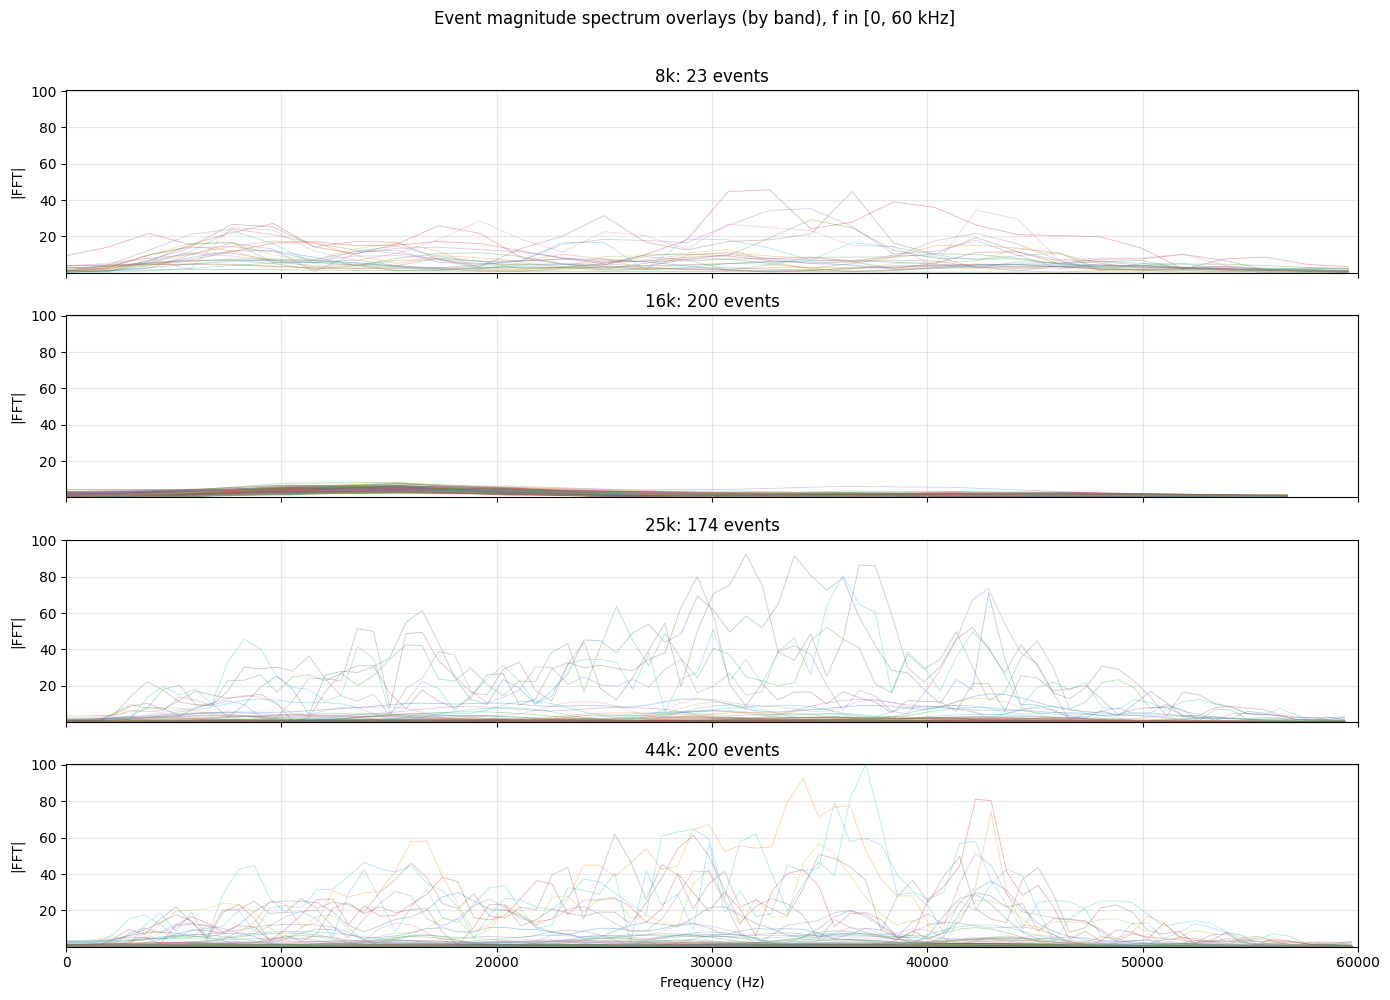

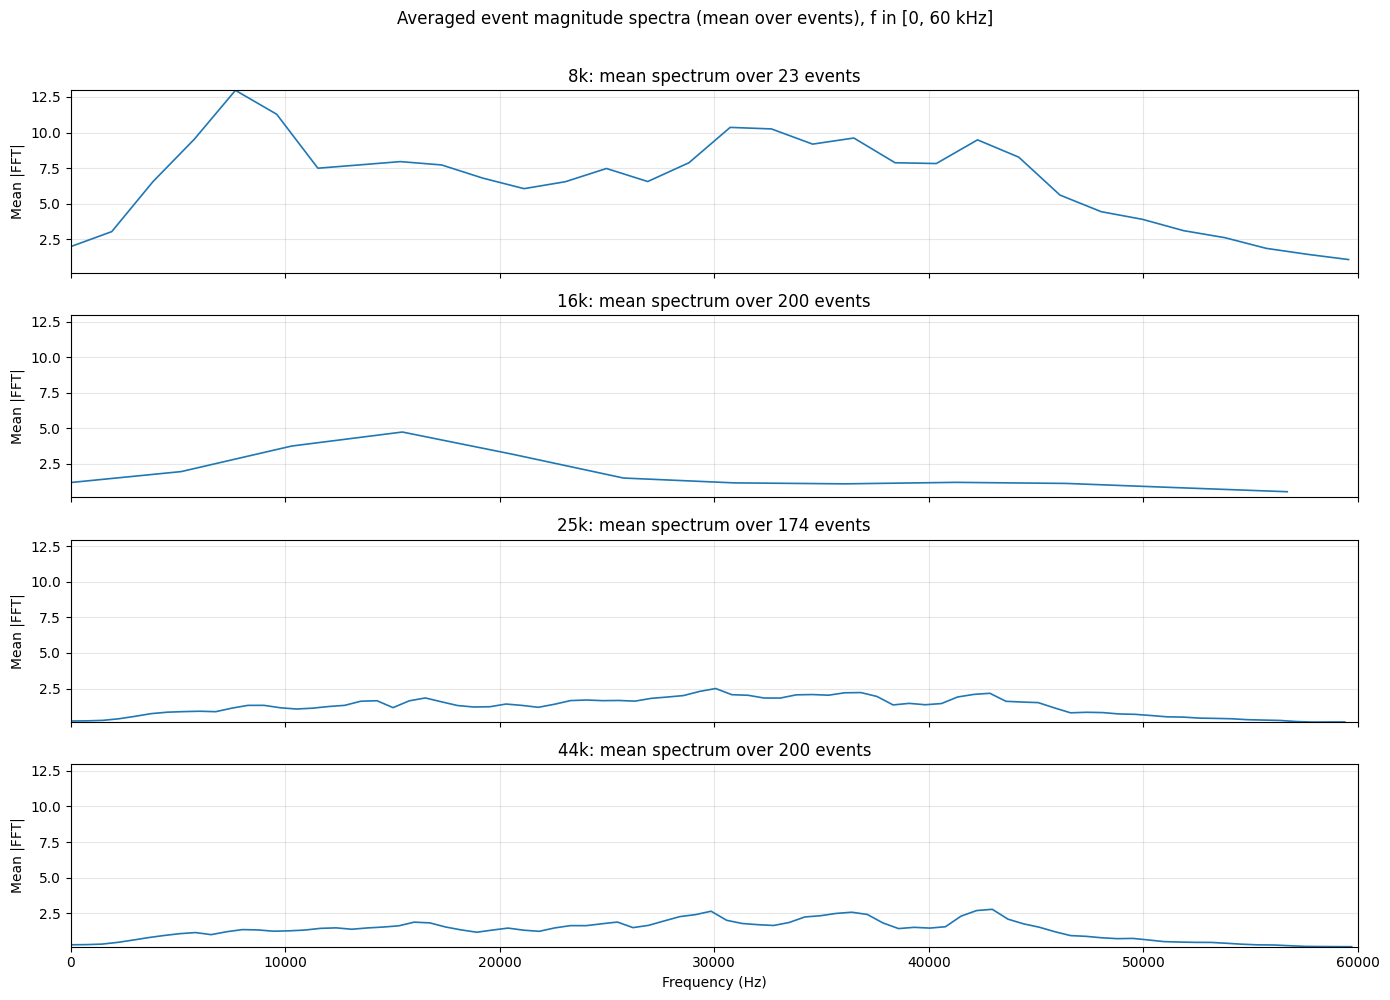

In [6]:
# ---------------- Example usage ----------------
segment_dir = "P36_filt_2k_60K_segments"
fs = 2_000_000
band_names = ["8k", "16k", "25k", "44k"]  # <-- your 4 bands

band_mags, band_avg, band_n = plot_overlaid_events_time_and_spectrum_4bands(
    segment_dir,
    fs,
    events_by_band,
    band_names,
    n_overlay_per_band=200,
    use_hann_window=True,
)

In [12]:
def load_1d_signal(path, fs=None):
    path = Path(path)

    if path.suffix.lower() == ".wav":
        from scipy.io import wavfile
        fs_read, x = wavfile.read(path)
        x = np.asarray(x, dtype=np.float32)
        if x.ndim == 2:
            x = x[:, 0]
        return x, float(fs_read)

    if path.suffix.lower() == ".npy":
        if fs is None:
            raise ValueError("For .npy input you must provide fs.")
        x = np.load(path)
        x = np.asarray(x, dtype=np.float32).squeeze()
        if x.ndim != 1:
            raise ValueError("Loaded .npy must be 1D.")
        return x, float(fs)

    raise ValueError(f"Unsupported file type: {path.suffix}")


def _plot_timeline_axes(
    ax,
    t_sig,
    x_sig,
    events_by_band,
    band_names,
    fs,
    *,
    colors=None,
    marker_size=25,
    title="",
    rail_offset_scale=0.15,
    rail_spacing_scale=0.10,
    font_title=18,
    font_label=14,
    font_ticks=12,
    show_legend=True,
):
    """
    Core plotting onto an existing axis (for full or zoomed views).
    Uses first 2 bands above 0, last 2 below 0.
    """
    if colors is None:
        colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    if len(band_names) != 4:
        raise ValueError("This plotting helper expects exactly 4 bands in band_names.")

    # Plot signal
    ax.plot(t_sig, x_sig, linewidth=0.6, color="lightgray", alpha=0.85)

    y_min = float(np.min(x_sig))
    y_max = float(np.max(x_sig))
    yr = y_max - y_min if (y_max > y_min) else 1.0

    rail_spacing = rail_spacing_scale * yr
    rail_offset = rail_offset_scale * yr

    rail_positions = [
        rail_offset + rail_spacing,
        rail_offset + 2 * rail_spacing,
        -rail_offset - rail_spacing,
        -rail_offset - 2 * rail_spacing,
    ]

    t0, t1 = float(t_sig[0]), float(t_sig[-1])

    # Rails + events
    for i, band in enumerate(band_names):
        y_level = rail_positions[i]

        ax.hlines(y_level, t0, t1, colors=colors[i], linewidth=2.0, alpha=0.6)

        evs = events_by_band.get(band, [])
        if evs:
            # event times from global start sample
            t_events = np.array([ev["event_global_start_sample"] for ev in evs], dtype=np.float64) / fs
            # keep only those within window
            mask = (t_events >= t0) & (t_events <= t1)
            t_events = t_events[mask]
            y_events = np.full_like(t_events, y_level, dtype=np.float64)

            ax.scatter(
                t_events, y_events,
                s=marker_size,
                color=colors[i],
                alpha=0.9,
                label=f"{band} ({mask.sum()} in window)" if show_legend else None
            )
        else:
            if show_legend:
                ax.scatter([], [], s=marker_size, color=colors[i], label=f"{band} (0)")

    # Cosmetics
    ax.set_title(title, fontsize=font_title)
    ax.set_xlabel("Time (s)", fontsize=font_label)
    ax.set_ylabel("Amplitude + Event Rails", fontsize=font_label)
    ax.tick_params(axis="both", labelsize=font_ticks)
    ax.grid(True, alpha=0.3)

    # Expand y to include rails
    y_extra = 3 * rail_spacing
    ax.set_ylim(y_min - y_extra, y_max + y_extra)

    if show_legend:
        ax.legend(fontsize=12, loc="upper right")


def plot_signal_with_band_event_timeline_and_zoom(
    raw_path,
    events_by_band,
    band_names,
    *,
    fs=None,
    decimate_to=500_000,
    marker_size=25,
    figsize_full=(16, 16),
    figsize_zoom=(16, 8),
    zoom_half_window_us=500.0,   # +/- 500 µs
):
    """
    Produces:
      1) Full timeline plot (decimated for speed)
      2) Zoomed plot around the global max |amplitude| at +/- zoom_half_window_us
    """

    x, fs = load_1d_signal(raw_path, fs=fs)
    N = len(x)
    t = np.arange(N) / fs

    # --------------------------
    # Plot 1: Full timeline
    # --------------------------
    if decimate_to is not None and N > decimate_to:
        step = int(np.ceil(N / decimate_to))
        x_full = x[::step]
        t_full = t[::step]
    else:
        x_full = x
        t_full = t

    fig = plt.figure(figsize=figsize_full)
    ax = fig.add_subplot(1, 1, 1)
    _plot_timeline_axes(
        ax,
        t_full,
        x_full,
        events_by_band,
        band_names,
        fs,
        marker_size=marker_size,
        title="Full Signal with Detected Event Timeline by Frequency Band",
        show_legend=True,
    )
    plt.tight_layout()
    plt.show()

    # --------------------------
    # Find global max |amplitude|
    # --------------------------
    idx_max = int(np.argmax(np.abs(x)))
    t_max = idx_max / fs

    half_win_s = (zoom_half_window_us * 1e-6)
    t0 = max(0.0, t_max - half_win_s)
    t1 = min(t[-1], t_max + half_win_s)

    i0 = int(np.floor(t0 * fs))
    i1 = int(np.ceil(t1 * fs))
    i0 = max(0, min(i0, N - 1))
    i1 = max(0, min(i1, N - 1))

    t_zoom = t[i0:i1 + 1]
    x_zoom = x[i0:i1 + 1]

    # --------------------------
    # Plot 2: Zoomed view
    # --------------------------
    fig = plt.figure(figsize=figsize_zoom)
    ax = fig.add_subplot(1, 1, 1)

    _plot_timeline_axes(
        ax,
        t_zoom,
        x_zoom,
        events_by_band,
        band_names,
        fs,
        marker_size=marker_size,
        title=f"Zoom around max |amplitude| at t={t_max:.6f} s (±{zoom_half_window_us:.0f} µs)",
        show_legend=True,
    )

    # Mark the max point
    ax.axvline(t_max, linestyle="--", linewidth=1.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(f"Max |amplitude| at sample {idx_max} (t={t_max:.6f} s). Zoom window: [{t0:.6f}, {t1:.6f}] s.")
    return {"idx_max": idx_max, "t_max_s": t_max, "zoom_i0": i0, "zoom_i1": i1, "fs": fs}


In [13]:
!ls


 AE_detection_results
 before_after_2bpf.png
 before_after_8KhzNpotch.png
 before_after_hpf.png
 hw1_prob2a.png
 P36_filt_20k_60K_segments
 P36_filt_2K_60K.npy
 P36_filt_2k_60K_segments
 P36_filtered_waveform_30-50_kHz.wav
 P36_filtered_waveform_32-46_kHz.wav
 P36_raw_segments
 P36_raw_waveform.wav
'Pillar 36_10um.DTA'
'Pillar 36_10um_Waveform20240721-194953-051.wfs'
 raw_signal_histogram.png
 raw_signal.png
 raw_signal_segments.png
 raw_signal_spectrogram.png


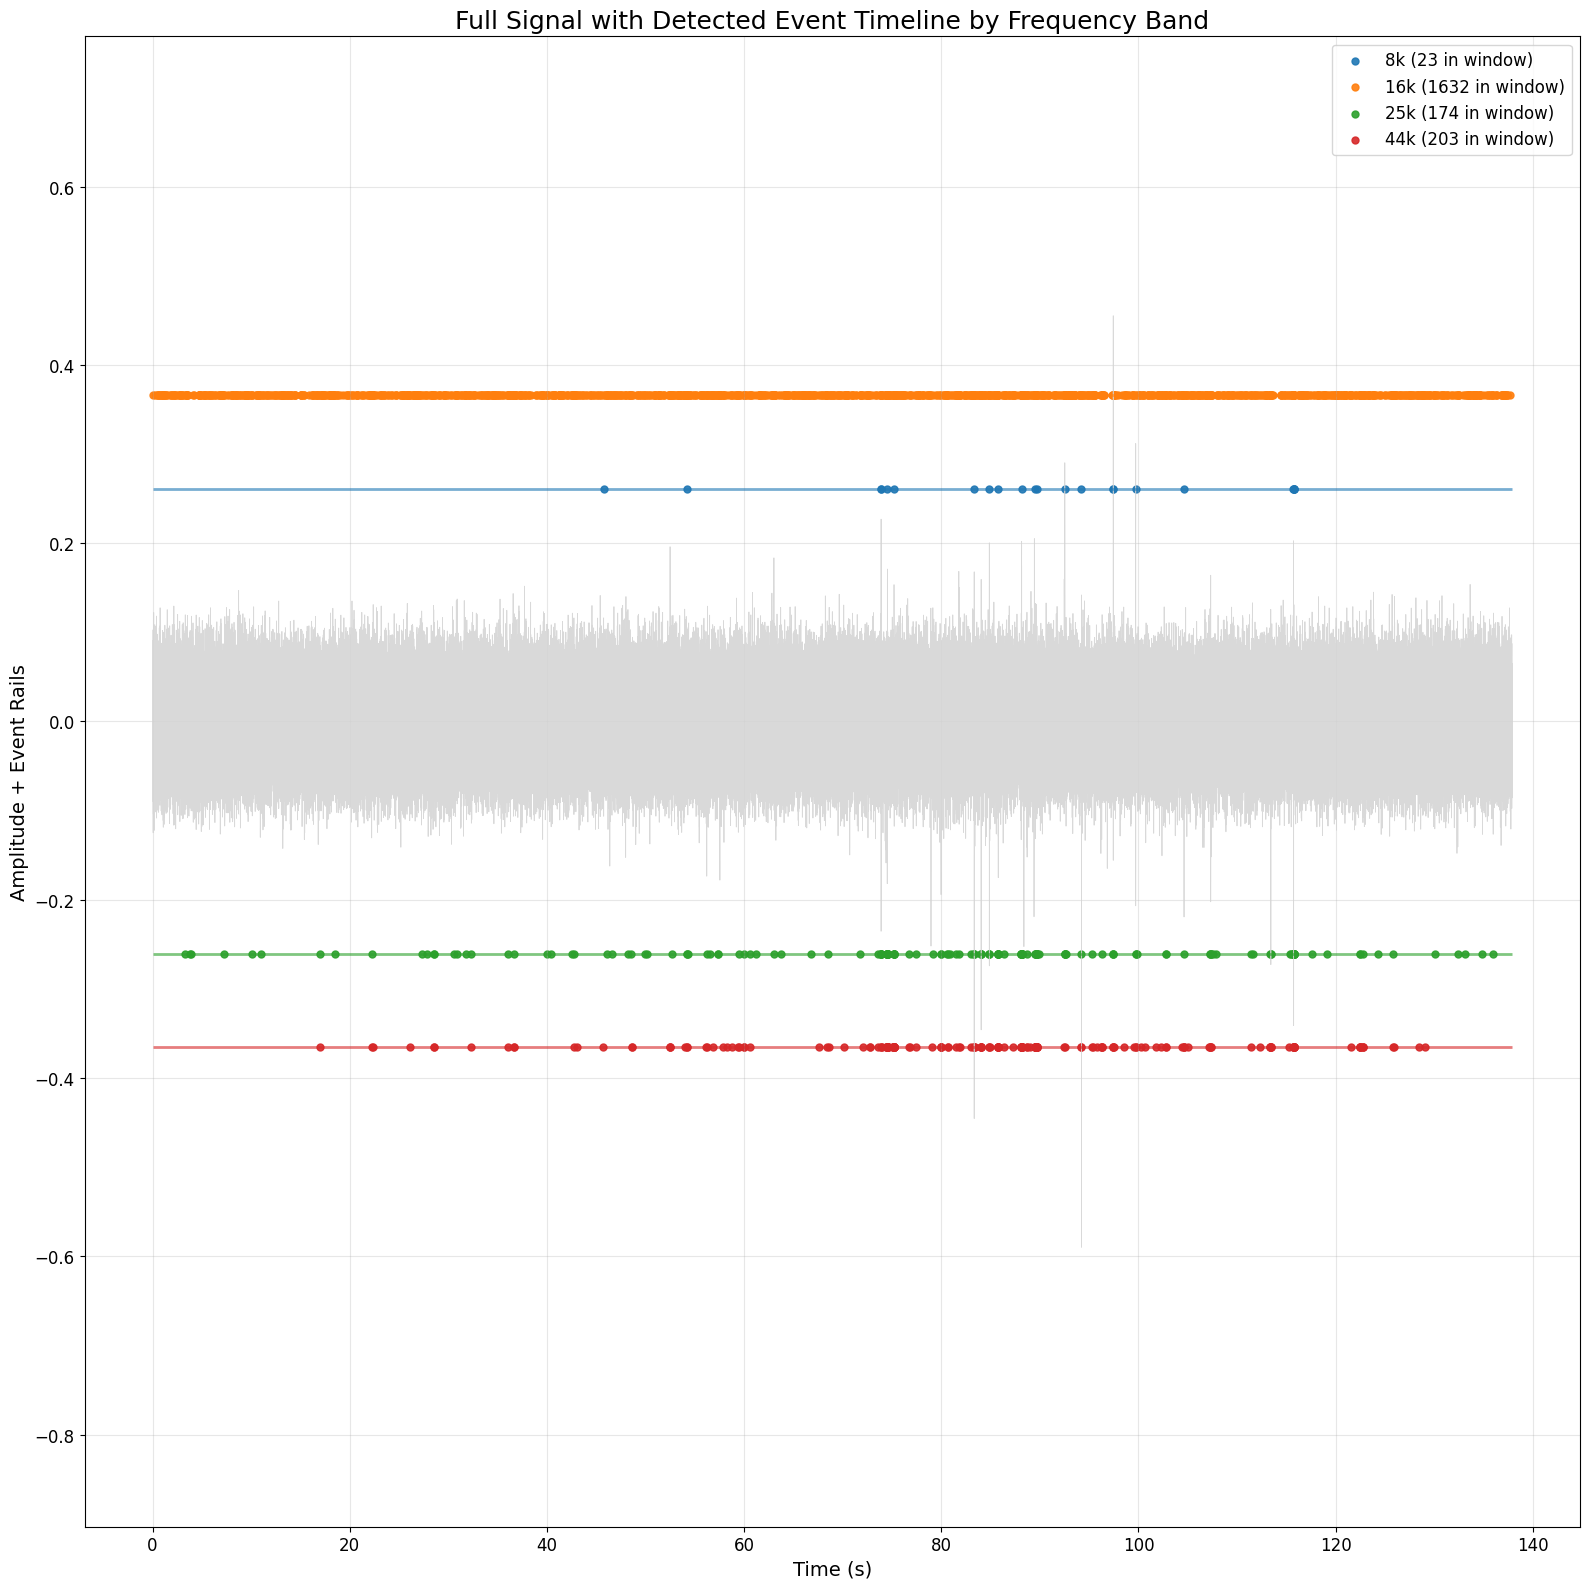

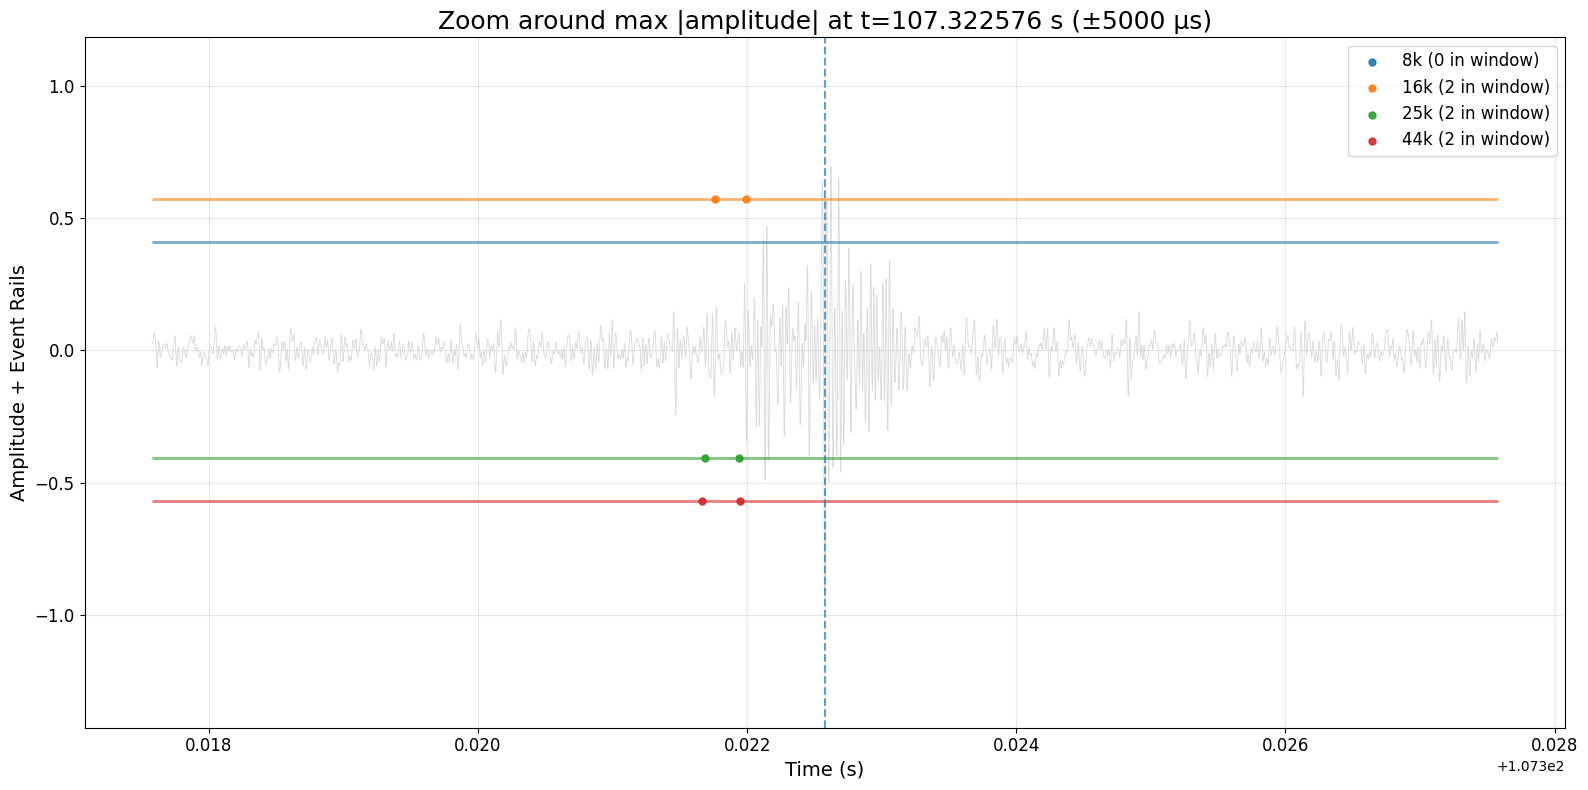

Max |amplitude| at sample 214645153 (t=107.322576 s). Zoom window: [107.317577, 107.327576] s.


In [14]:
# ---------------- Example usage ----------------
raw_path = "P36_filt_2K_60K.npy"   # you’ll provide this
band_names = ["8k", "16k", "25k", "44k"]         # your 4 bands

info = plot_signal_with_band_event_timeline_and_zoom(
    raw_path,
    events_by_band,
    band_names,
    fs=2_000_000,          # only needed if raw_path is .npy
    zoom_half_window_us=5000.0,
)

### Extract the Events


What i'd like to do now is generate code to extract a set of 'event signals' as well as a set of 'non-event signals'. The 'event signals' are snippets of the signal where a seismic event is taking place and the 'non-event signals' are snippets of no activity. I want to create a dictionary of these as follows:

For the 'event signals':
1. Use the data structures already computed and stored. In particular the 'events_by'band' data structure.
2. We will ignore the 16K 'band' but use the other 3 ('8k', '25k', and '44k')
3. For each band extract the time signal from the original waveform and add it to the dictionary with the following keys:
- An index into the event number. The event number should reflect the chronological order of the snippet. So the earlies snippet should have an event number of 0, then next one as 1, etc.
- The same keys and values from 'events_by_band', namely 'band', 'filename', 'file_start_index', etc.
- The signal snippet with duration of the event given. If the file ends before the duration then pull the rest of of the signal from the subsequent file
- The magnitude spectrum of the signal snippet
4. Make sure the snippets are ordered in the dictionary by index event number
5. When done store this resulting dictionary as the file 'event_signals_8K_25K_44K'

When done print out the number of events and stats on the durations: min, median, average, max, stdev.


Below is drop-in Python code that uses the existing events_by_band structure from the notebook, ignores 16k, and builds an ordered dictionary of event snippets for 8k / 25k / 44k. It:

merges events across those bands

sorts them chronologically (by event_global_start_sample)

assigns event_number = 0,1,2,… in that chronological order

extracts the time-domain snippet from the original segmented .npy files, spanning across files if needed

computes a magnitude spectrum (rfft)

saves to a pickle file named event_signals_8K_25K_44K.pkl

prints count + duration stats (min/median/mean/max/stdev)

Assumes you already have the helper functions from your notebook available:
list_segment_files(), parse_segment_bounds_from_filename()
(I re-use them as-is.)

Notes / design choices (matching your requirements)

Chronological indexing: We merge 8k/25k/44k events then sort by event_global_start_sample; that ordering defines event_number.

Spanning across files: _read_global_interval() reads global [start,end] and concatenates slices across segments if it crosses boundaries.

Spectrum: one-sided magnitude spectrum via np.fft.rfft; also stores matching spectrum_freq_hz so it’s usable later.

Storage format: Pickle is the simplest for a dictionary holding NumPy arrays. File written as event_signals_8K_25K_44K.pkl.


In [8]:
import numpy as np
import pickle
from pathlib import Path

def _build_segment_index(segment_dir, prefix="P36_filt"):
    """
    Build a sorted list of segments:
      [{"path": Path, "start": int, "end_inc": int}, ...]
    and validate they are ordered and (optionally) contiguous.
    """
    files = list_segment_files(segment_dir, prefix=prefix)
    segs = []
    for fp in files:
        s, e = parse_segment_bounds_from_filename(fp.name)
        segs.append({"path": fp, "start": int(s), "end_inc": int(e)})

    segs.sort(key=lambda d: d["start"])
    return segs

def _read_global_interval(segs, g0, g1_inc):
    """
    Read samples from global index g0..g1_inc inclusive across segmented files.
    Spans multiple files if needed.
    """
    if g1_inc < g0:
        raise ValueError("g1_inc must be >= g0")

    parts = []
    need_start = int(g0)
    need_end = int(g1_inc)

    # Find first segment that could contain need_start
    # (linear scan is fine for moderate #files; can be optimized if needed)
    i = 0
    while i < len(segs) and segs[i]["end_inc"] < need_start:
        i += 1

    while need_start <= need_end:
        if i >= len(segs):
            raise ValueError(f"Ran out of segment files while reading [{g0}, {g1_inc}]")

        seg = segs[i]
        seg_start = seg["start"]
        seg_end = seg["end_inc"]

        # If there's a gap in coverage, fail loudly
        if need_start < seg_start:
            raise ValueError(
                f"Global index gap: need_start={need_start} but next seg starts at {seg_start}"
            )

        # Portion to take from this segment
        take_start = need_start
        take_end = min(need_end, seg_end)

        # Convert to file-local indices
        local_s = take_start - seg_start
        local_e_inc = take_end - seg_start

        x = np.load(seg["path"], mmap_mode="r")
        parts.append(np.asarray(x[local_s : local_e_inc + 1], dtype=np.float32))

        need_start = take_end + 1
        i += 1

    return np.concatenate(parts) if len(parts) > 1 else parts[0]

def build_event_signal_dictionary(
    events_by_band,
    segment_dir,
    fs,
    *,
    prefix="P36_filt",
    bands_keep=("8k", "25k", "44k"),
    out_basename="event_signals_8K_25K_44K",
):
    """
    Create an ordered dict-like structure:
      event_signals[event_number] = {
        ... metadata from events_by_band event dict ...
        "event_number": int,
        "signal": np.ndarray (float32),
        "spectrum_mag": np.ndarray,
        "spectrum_freq_hz": np.ndarray,
      }
    """
    segs = _build_segment_index(segment_dir, prefix=prefix)

    # 1) Gather events from selected bands
    merged = []
    for band in bands_keep:
        for ev in events_by_band.get(band, []):
            merged.append(ev)

    # 2) Sort chronologically across bands
    merged.sort(key=lambda d: d["event_global_start_sample"])

    # 3) Build dictionary ordered by event_number
    event_signals = {}
    durations_s = []

    for k, ev in enumerate(merged):
        g0 = int(ev["event_global_start_sample"])
        g1 = int(ev["event_global_end_sample_inclusive"])  # inclusive

        # Extract snippet across file boundaries if needed
        snippet = _read_global_interval(segs, g0, g1)

        # Duration from snippet length (more direct than stored duration_us)
        dur_s = len(snippet) / float(fs)
        durations_s.append(dur_s)

        # Magnitude spectrum (one-sided)
        X = np.fft.rfft(snippet)
        mag = np.abs(X)
        freqs = np.fft.rfftfreq(len(snippet), d=1.0 / float(fs))

        # Store: keep ALL original event keys + required additions
        rec = dict(ev)  # includes band, filename, file_start_idx, etc.
        rec["event_number"] = k
        rec["signal"] = snippet
        rec["spectrum_mag"] = mag
        rec["spectrum_freq_hz"] = freqs

        event_signals[k] = rec

    # 4) Save to disk
    out_path = Path(f"{out_basename}.pkl")
    with open(out_path, "wb") as f:
        pickle.dump(event_signals, f, protocol=pickle.HIGHEST_PROTOCOL)

    # 5) Print stats
    durations_s = np.asarray(durations_s, dtype=np.float64)
    if durations_s.size:
        stats = {
            "count": int(durations_s.size),
            "min_s": float(np.min(durations_s)),
            "median_s": float(np.median(durations_s)),
            "mean_s": float(np.mean(durations_s)),
            "max_s": float(np.max(durations_s)),
            "stdev_s": float(np.std(durations_s, ddof=0)),
        }
    else:
        stats = {"count": 0}

    print(f"Saved: {out_path}")
    print(f"Number of events (bands {bands_keep}): {stats['count']}")
    if stats["count"] > 0:
        print(
            "Duration stats (seconds): "
            f"min={stats['min_s']:.6g}, median={stats['median_s']:.6g}, "
            f"mean={stats['mean_s']:.6g}, max={stats['max_s']:.6g}, "
            f"stdev={stats['stdev_s']:.6g}"
        )

    return event_signals, stats, out_path


In [9]:
# Example call (after you already computed events_by_band in the notebook):
event_signals, stats, out_path = build_event_signal_dictionary(
    events_by_band, segment_dir="P36_filt_2k_60K_segments", fs=2_000_000,
    prefix="P36_filt", bands_keep=("8k","25k","44k"),
    out_basename="event_signals_8K_25K_44K"
)

Saved: event_signals_8K_25K_44K.pkl
Number of events (bands ('8k', '25k', '44k')): 400
Duration stats (seconds): min=0.0001, median=0.00013275, mean=0.000196594, max=0.0013735, stdev=0.000187256


In [11]:
print(event_signals[0])

{'band': '25k', 'filename': 'P36_filt_6000000_7999999.npy', 'file_start_idx': 496922, 'file_end_idx_inclusive': 497139, 'segment_global_start_sample': 6000000, 'event_global_start_sample': 6496922, 'event_global_end_sample_inclusive': 6497139, 'global_start_time_s': 3.248461, 'duration_us': 109.0, 'threshold_used': 1.3835881327331065, 'event_number': 0, 'signal': array([-0.02116959, -0.01838696, -0.01512246, -0.01140164, -0.00726089,
       -0.00274613,  0.00208865,  0.0071831 ,  0.01247246,  0.01788951,
        0.02336654,  0.0288373 ,  0.03423874,  0.03951259,  0.04460669,
        0.04947604,  0.05408349,  0.05840014,  0.06240544,  0.0660869 ,
        0.0694396 ,  0.07246535,  0.07517178,  0.07757108,  0.07967879,
        0.08151241,  0.08309011,  0.08442938,  0.08554586,  0.08645228,
        0.08715755,  0.0876662 ,  0.08797789,  0.08808729,  0.08798423,
        0.08765404,  0.08707818,  0.08623509,  0.08510119,  0.08365205,
        0.08186358,  0.0797134 ,  0.07718199,  0.07425398,

### Combine the events into a set of unique ones without overlap

Next I want to create a union version of the events across the snippets. If two or more of the snippets overlap in time I want to merge them into a single longer snippet. Namely if the end index of one snippet lies within the [start_idx, end_idx] of another, I want to merge those two into a single snippet with the start equal to the min of the start indices and the end equal to the max of the end indices. Do this for all the signals until the resulting snippets have no overlap. Store these in a dictionary with
- A combined event index number reflecting the chronological order of combined events
- A reference to the all the event numbers combined into this single snippet (make this a list of event numbers)
- the global start index, global end index, global start time, global end time
- The combined signal
- The combined signal duration
- The combined signal magnitude spectrum
Make sure the combined snippets are ordered in the dictionary by combined index event number
When done store this resulting dictionary as the file 'event_signals_8K_25K_44K_combined'

Below is code that takes the event_signals dict you built previously (keyed by event_number in chronological order), merges any overlapping events into union/combined events, extracts the combined waveform across segment files, computes duration + spectrum, and saves:

event_signals_8K_25K_44K_combined.pkl

It implements your overlap rule and repeats merging until none remain (the standard interval-union scan does this in one pass once sorted).

In [13]:
import numpy as np
import pickle
from pathlib import Path

def combine_overlapping_event_snippets(
    event_signals,
    segment_dir,
    fs,
    *,
    prefix="P36_filt",
    out_basename="event_signals_8K_25K_44K_combined",
):
    segs = _build_segment_index(segment_dir, prefix=prefix)

    # Collect base intervals
    base = []
    for ev_num, rec in event_signals.items():
        g0 = int(rec["event_global_start_sample"])
        g1 = int(rec["event_global_end_sample_inclusive"])
        base.append({
            "event_number": int(ev_num),
            "g0": g0,
            "g1": g1,
        })

    if not base:
        combined = {}
        out_path = Path(f"{out_basename}.pkl")
        with open(out_path, "wb") as f:
            pickle.dump(combined, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Saved: {out_path} (no events)")
        return combined, out_path

    base.sort(key=lambda d: (d["g0"], d["g1"]))

    # Merge overlaps
    merged_groups = []
    cur = {
        "g0": base[0]["g0"],
        "g1": base[0]["g1"],
        "event_numbers": [base[0]["event_number"]],
    }

    for item in base[1:]:
        g0, g1, evn = item["g0"], item["g1"], item["event_number"]

        if g0 <= cur["g1"]:   # overlap (inclusive)
            cur["g1"] = max(cur["g1"], g1)
            cur["event_numbers"].append(evn)
        else:
            merged_groups.append(cur)
            cur = {"g0": g0, "g1": g1, "event_numbers": [evn]}

    merged_groups.append(cur)

    # Build combined dict
    combined_events = {}
    durations = []

    for comb_idx, grp in enumerate(merged_groups):
        g0 = int(grp["g0"])
        g1 = int(grp["g1"])

        sig = _read_global_interval(segs, g0, g1)

        t0 = g0 / float(fs)
        t1 = (g1 + 1) / float(fs)
        dur_s = len(sig) / float(fs)

        durations.append(dur_s)

        X = np.fft.rfft(sig)
        mag = np.abs(X)
        freqs = np.fft.rfftfreq(len(sig), d=1.0 / float(fs))

        combined_events[comb_idx] = {
            "combined_event_number": comb_idx,
            "event_numbers": sorted(grp["event_numbers"]),
            "global_start_sample": g0,
            "global_end_sample_inclusive": g1,
            "global_start_time_s": t0,
            "global_end_time_s": t1,
            "duration_s": dur_s,
            "signal": sig,
            "spectrum_mag": mag,
            "spectrum_freq_hz": freqs,
        }

    # Save
    out_path = Path(f"{out_basename}.pkl")
    with open(out_path, "wb") as f:
        pickle.dump(combined_events, f, protocol=pickle.HIGHEST_PROTOCOL)

    # Print stats
    durations = np.asarray(durations, dtype=np.float64)

    print(f"Saved: {out_path}")
    print(f"Combined events: {len(combined_events)} (from {len(event_signals)} original events)")

    if len(durations) > 0:
        print("Combined duration stats (seconds):")
        print(f"  Count  : {len(durations)}")
        print(f"  Min    : {np.min(durations):.6g}")
        print(f"  Median : {np.median(durations):.6g}")
        print(f"  Mean   : {np.mean(durations):.6g}")
        print(f"  Max    : {np.max(durations):.6g}")
        print(f"  Stdev  : {np.std(durations, ddof=0):.6g}")

    return combined_events, out_path

In [14]:
# Example usage (after building event_signals in the previous step):
combined_events, out_path = combine_overlapping_event_snippets(
    event_signals,
    segment_dir="P36_filt_2k_60K_segments",
    fs=2_000_000,
    prefix="P36_filt",
    out_basename="event_signals_8K_25K_44K_combined"
)

Saved: event_signals_8K_25K_44K_combined.pkl
Combined events: 266 (from 400 original events)
Combined duration stats (seconds):
  Count  : 266
  Min    : 0.0001
  Median : 0.00012675
  Mean   : 0.000202583
  Max    : 0.0015405
  Stdev  : 0.000219956


### Non-Event snippets

Finally I need a set of 'non-event signals. For this we will sample the portions of the signal where no events occur. For this, take a desired number of samples, say 10 times the number of combined event signals. Then extract snippets from the original signal as follows:
- Sample uniformly over the entire duration of the waveform
- Make sure the non-event sample does not overlap with any of the combined event signals. If one does discard it and pick another until we get a sample that does not overlap with any combined event snippet
- For each snippet include the same key parameters thay make up the combined event dictionary
- Store these snippets in their own dictionary called 'non_event_signals'


Below is drop-in code to generate non-event snippets sampled uniformly over the full waveform, rejecting anything that overlaps any of the combined event intervals, and returning/saving a dictionary non_event_signals with the same core fields as your combined-event dictionary (start/end indices & times, duration, signal, spectrum).

I’m assuming:

you already have combined_events from the previous step

you still have the helper functions we used earlier in the notebook/code:

_build_segment_index(segment_dir, prefix=...)

_read_global_interval(segs, g0, g1_inc)

If those helpers aren’t in your namespace, paste them from the earlier step.

Why this matches your requirements

Uniform sampling over full waveform: start indices are drawn uniformly from the valid global index range.

No overlap with combined events: _overlaps_any() rejects candidates that intersect any combined interval.

Same key parameters as combined-event dictionary: start/end sample indices & times, duration, signal, spectrum magnitude + frequency axis.

Desired number of samples: multiplier * len(combined_events) (default 10×).

Stored in dictionary named non_event_signals: returned as that dict, and also saved to disk.

No — in the code I gave you, the non-event snippets are not all the same duration.

They are sampled from the empirical duration distribution of the combined events:

event_lengths = [...]
L = int(rng.choice(event_lengths))

So each non-event snippet:

Has a length equal to one randomly chosen combined-event duration

Therefore matches the distribution of event durations

But is not fixed length

Why I did it that way

This keeps the non-event dataset statistically comparable to the event dataset in duration distribution, which is often desirable for classification tasks.

In [15]:
import numpy as np
import pickle
from pathlib import Path
import bisect

def _combined_intervals_sorted(combined_events):
    """
    Return sorted, non-overlapping combined event intervals:
      intervals = [(start, end_inc), ...] sorted by start
    """
    intervals = []
    for _, rec in combined_events.items():
        intervals.append((
            int(rec["global_start_sample"]),
            int(rec["global_end_sample_inclusive"])
        ))
    intervals.sort(key=lambda x: x[0])
    return intervals

def _overlaps_any(intervals, start, end_inc):
    """
    intervals: sorted list of (s,e) non-overlapping
    check if [start, end_inc] overlaps any interval.
    """
    # Find rightmost interval with s <= start
    starts = [s for s, _ in intervals]
    i = bisect.bisect_right(starts, start) - 1

    # Check overlap with interval i
    if i >= 0:
        s, e = intervals[i]
        if start <= e and end_inc >= s:
            return True

    # Check overlap with next interval i+1
    j = i + 1
    if j < len(intervals):
        s, e = intervals[j]
        if start <= e and end_inc >= s:
            return True

    return False

def build_non_event_signals(
    combined_events,
    segment_dir,
    fs,
    *,
    prefix="P36_filt",
    multiplier=10,
    rng_seed=0,
    out_basename="non_event_signals_8K_25K_44K_combined",
    max_attempts_factor=200,
):
    """
    Create non-event snippets by uniform random sampling over the entire waveform duration,
    rejecting any candidate snippet that overlaps any combined-event interval.

    Snippet lengths:
      - To make these comparable to events, we sample a duration (in samples) from the
        empirical distribution of combined event durations.

    Returns:
      non_event_signals (dict): non_event_number -> record (same core keys as combined_events)
      out_path (Path)
    """
    if len(combined_events) == 0:
        raise ValueError("combined_events is empty; cannot derive snippet durations.")

    rng = np.random.default_rng(rng_seed)

    # Segment index for reading raw waveform across files
    segs = _build_segment_index(segment_dir, prefix=prefix)

    # Determine global signal coverage
    global_start = int(segs[0]["start"])
    global_end_inc = int(segs[-1]["end_inc"])
    total_len = global_end_inc - global_start + 1

    # Combined-event intervals (already unioned; non-overlapping)
    intervals = _combined_intervals_sorted(combined_events)

    # Sample target count
    n_target = multiplier * len(combined_events)

    # Empirical duration distribution (in samples)
    event_lengths = np.array([
        int(rec["global_end_sample_inclusive"]) - int(rec["global_start_sample"]) + 1
        for rec in combined_events.values()
    ], dtype=int)

    # Storage
    non_event_signals = {}
    durations = []

    attempts = 0
    max_attempts = max_attempts_factor * n_target

    while len(non_event_signals) < n_target and attempts < max_attempts:
        attempts += 1

        # Pick a random event-like length (in samples)
        L = int(rng.choice(event_lengths))
        if L <= 0:
            continue

        # Choose uniform start so that snippet fits in global bounds
        # (global indices are inclusive)
        max_start = global_end_inc - (L - 1)
        if max_start < global_start:
            continue

        g0 = int(rng.integers(global_start, max_start + 1))
        g1 = g0 + L - 1

        # Reject if overlaps any combined event
        if _overlaps_any(intervals, g0, g1):
            continue

        # Extract waveform snippet
        sig = _read_global_interval(segs, g0, g1)

        # Times & duration
        t0 = g0 / float(fs)
        t1 = (g1 + 1) / float(fs)  # boundary after last sample
        dur_s = len(sig) / float(fs)
        durations.append(dur_s)

        # Spectrum
        X = np.fft.rfft(sig)
        mag = np.abs(X)
        freqs = np.fft.rfftfreq(len(sig), d=1.0 / float(fs))

        idx = len(non_event_signals)
        non_event_signals[idx] = {
            "non_event_number": idx,
            "global_start_sample": g0,
            "global_end_sample_inclusive": g1,
            "global_start_time_s": t0,
            "global_end_time_s": t1,
            "duration_s": dur_s,
            "signal": sig,
            "spectrum_mag": mag,
            "spectrum_freq_hz": freqs,
        }

    if len(non_event_signals) < n_target:
        print(
            f"WARNING: Only collected {len(non_event_signals)} / {n_target} non-event snippets "
            f"after {attempts} attempts. (Try lowering multiplier, lowering max event duration, "
            f"or increasing max_attempts_factor.)"
        )

    # Save
    out_path = Path(f"{out_basename}.pkl")
    with open(out_path, "wb") as f:
        pickle.dump(non_event_signals, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Saved: {out_path}")
    print(f"Non-event snippets collected: {len(non_event_signals)} (target was {n_target})")

    # Optional: print duration stats (often useful)
    durations = np.asarray(durations, dtype=np.float64)
    if durations.size:
        print("Non-event duration stats (seconds):")
        print(f"  Count  : {len(durations)}")
        print(f"  Min    : {np.min(durations):.6g}")
        print(f"  Median : {np.median(durations):.6g}")
        print(f"  Mean   : {np.mean(durations):.6g}")
        print(f"  Max    : {np.max(durations):.6g}")
        print(f"  Stdev  : {np.std(durations, ddof=0):.6g}")

    return non_event_signals, out_path

In [16]:
# Example usage:
non_event_signals, out_path = build_non_event_signals(
    combined_events,
    segment_dir="P36_filt_2k_60K_segments",
    fs=2_000_000,
    prefix="P36_filt",
    multiplier=10,
    rng_seed=123,
    out_basename="non_event_signals_8K_25K_44K_combined",
)

Saved: non_event_signals_8K_25K_44K_combined.pkl
Non-event snippets collected: 2660 (target was 2660)
Non-event duration stats (seconds):
  Count  : 2660
  Min    : 0.0001
  Median : 0.000126
  Mean   : 0.000201579
  Max    : 0.0015405
  Stdev  : 0.000221091


### Data Visualization: Combined Events

Here's an idea for data visualization. Tell me if you can do this. Now that we have combined events and non-events, i want to show these as a movie. Namely:
1.  join the combined events with the non-events into a single chronological array of time plots, ordered by global time start index
2. Plot this sequentially to look like a movie. Keep a fixed interval between the plots
3. On each plot print the start time
4. Keep a fixed set of global plot x and y limits so that all the plots fit on the same set of axes. Is this doable?

You already have everything needed (global start indices/times + signals). The workflow is:

Merge combined-events + non-events into one list

Sort by global_start_sample (chronological)

Compute global axis limits (fixed x/y for every frame)

x: either fixed duration (recommended) or fixed [0, max_duration]

y: fixed [-1, 1] (since your signal is normalized) or compute from all snippets

Render frames sequentially with a fixed pause (simple “movie” in-notebook), or write an actual MP4/GIF.

Below are two versions:

A. In-notebook “movie” using plt.pause() (quick)

B. Export MP4 using matplotlib.animation (real movie file)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def play_combined_events_movie(
    combined_events,
    fs,
    *,
    frame_interval_s=0.2,
    ylims=(-1, 1),
    max_seconds=None,
    max_frames=None,
):
    """
    Plays combined events sequentially as a movie.

    Parameters
    ----------
    combined_events : dict
        Output from combine_overlapping_event_snippets()
    fs : float
        Sampling frequency
    frame_interval_s : float
        Delay between frames
    ylims : tuple
        Fixed y-axis limits
    max_seconds : float or None
        Fixed x-axis length (seconds). If None, uses max snippet duration.
    max_frames : int or None
        Optional limit for testing
    """

    # Sort chronologically
    seq = sorted(
        combined_events.values(),
        key=lambda r: r["global_start_sample"]
    )

    if max_frames is not None:
        seq = seq[:int(max_frames)]

    if not seq:
        raise ValueError("No combined events to display.")

    # Determine fixed x-axis range
    if max_seconds is None:
        max_len = max(len(rec["signal"]) for rec in seq)
        max_seconds = max_len / float(fs)

    xlim = (0.0, float(max_seconds))

    for i, rec in enumerate(seq):
        sig = np.asarray(rec["signal"])
        t = np.arange(len(sig)) / float(fs)

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(t, sig, lw=1)

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylims)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.grid(True)

        ax.set_title(
            f"Combined Event {rec['combined_event_number']}  |  "
            f"Start = {rec['global_start_time_s']:.6f} s"
        )

        clear_output(wait=True)
        display(fig)
        plt.close(fig)

        time.sleep(frame_interval_s)

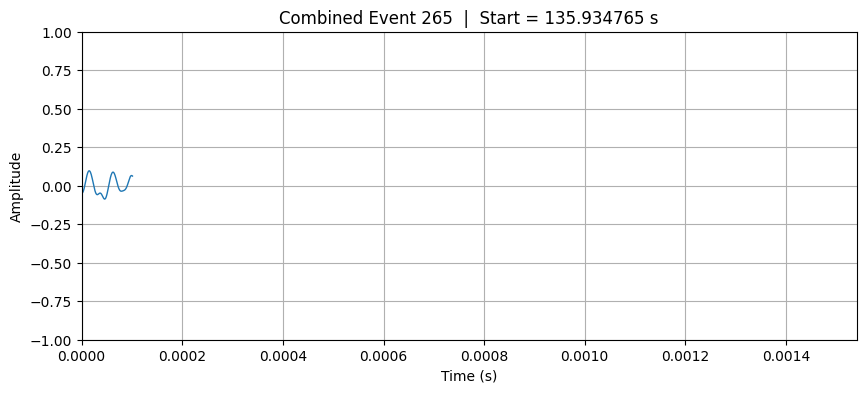

In [27]:
play_combined_events_movie(
    combined_events,
    fs=2_000_000,
    frame_interval_s=0.1,
    ylims=(-1, 1),
    max_frames=266  # optional
)

### One big plot of combined events

We’ll:

Take the first 260 combined events

Create a 26 × 10 grid

Use fixed global x and y limits

Print on each subplot:

Combined event index

Start time (seconds)

Because this is a large figure (260 subplots), we’ll:

Keep labels minimal

Use small fonts

Avoid heavy styling for speed


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_combined_events_grid(
    combined_events,
    fs,
    *,
    n_rows=26,
    n_cols=10,
    ylims=(-1, 1),
):
    """
    Plot first n_rows * n_cols combined events
    in a large grid layout with:
      - grid lines
      - time scale on bottom row
      - larger readable fonts
    """

    n_plots = n_rows * n_cols

    # Sort chronologically
    seq = sorted(
        combined_events.values(),
        key=lambda r: r["global_start_sample"]
    )

    if len(seq) < n_plots:
        print(f"Warning: Only {len(seq)} combined events available.")
        n_plots = len(seq)
        seq = seq[:n_plots]
    else:
        seq = seq[:n_plots]

    # Fixed x-axis range
    max_len = max(len(rec["signal"]) for rec in seq)
    max_seconds = max_len / float(fs)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(24, 48),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    for i, (ax, rec) in enumerate(zip(axes, seq)):
        sig = np.asarray(rec["signal"])
        t = np.arange(len(sig)) / float(fs)

        ax.plot(t, sig, lw=0.8)
        ax.set_xlim(0.0, max_seconds)
        ax.set_ylim(*ylims)

        ax.grid(True, linewidth=0.3, alpha=0.6)

        ax.set_title(
            f"{rec['combined_event_number']} | {rec['global_start_time_s']:.4f}s",
            fontsize=9
        )

        # Hide x tick labels except bottom row
        row = i // n_cols
        if row < n_rows - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Time (s)", fontsize=10)

        # Hide y tick labels except first column
        col = i % n_cols
        if col != 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel("Amp", fontsize=10)

    # Turn off unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

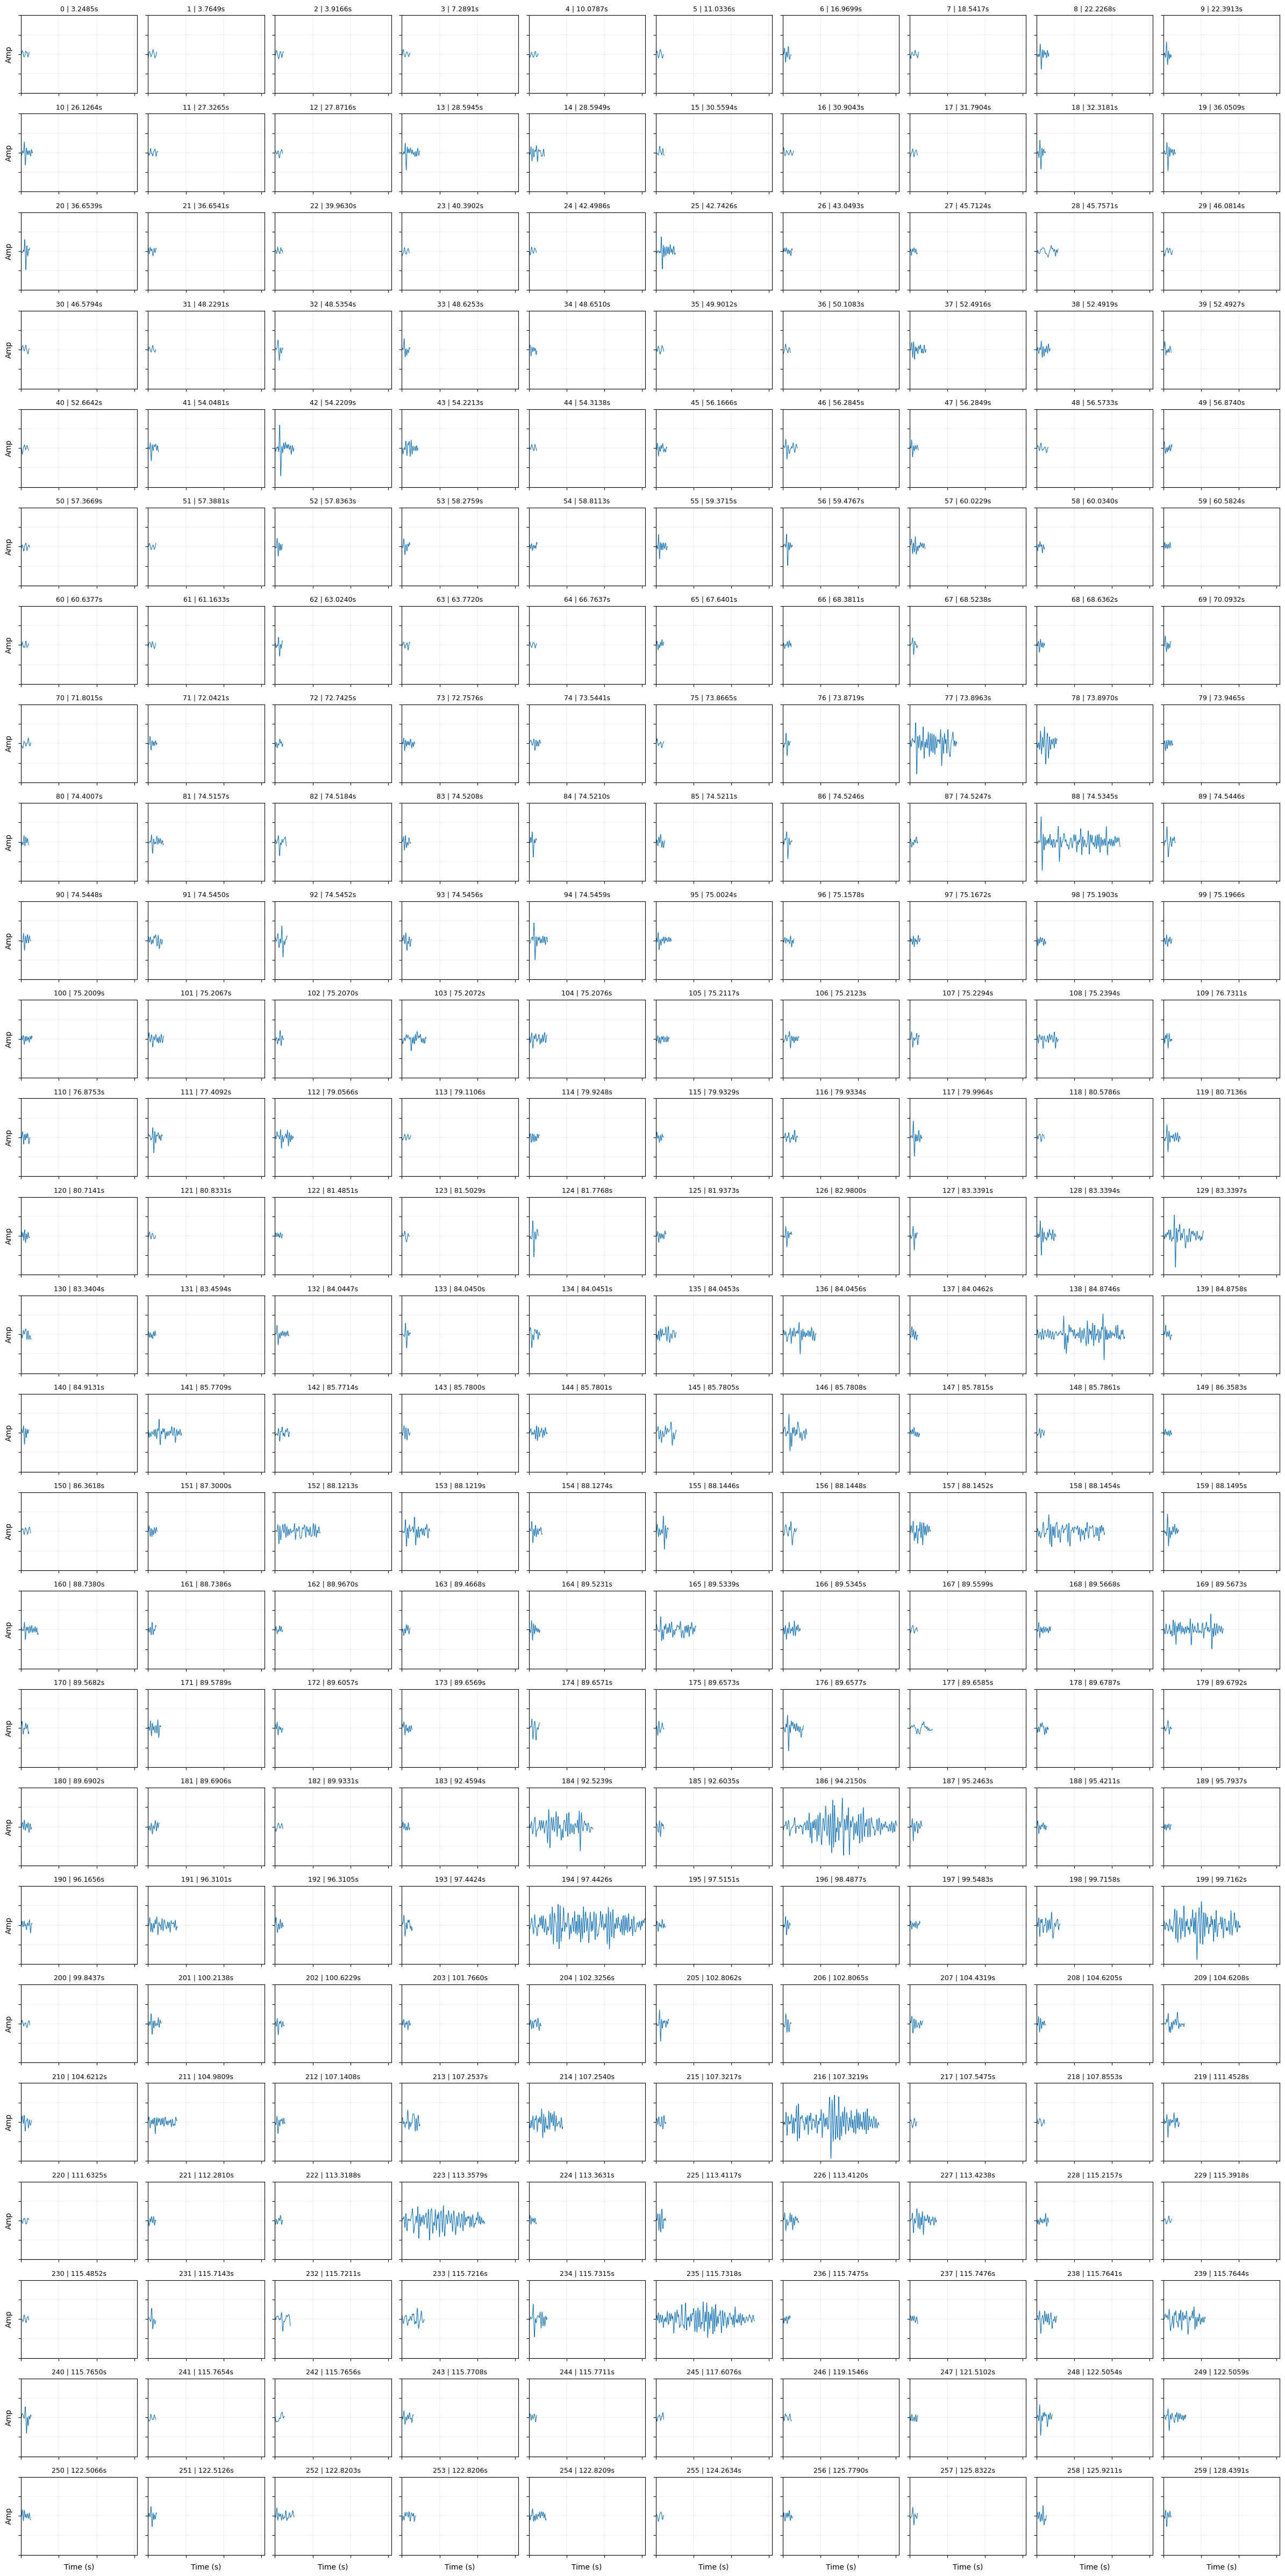

In [32]:
plot_combined_events_grid(
    combined_events,
    fs=2_000_000,
    n_rows=26,
    n_cols=10,
    ylims=(-1, 1)
)

In [28]:
print(len(combined_events))

266
